### GLobalna analiza performansi i poredjenje modela

In [1]:
from pathlib import Path 
import json 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_style("whitegrid")

In [3]:
RESULTS_DIR = Path("../results")

def load_model_metrics(results_dir: Path): 
    rows = []

    for model_dir in results_dir.iterdir():
        if not model_dir.is_dir():
            continue
        
        metrics_path = model_dir / "metrics.json"
        if not metrics_path.exists():
            print(f"file metrics.json does not exists in {model_dir}")
            continue

        with open(metrics_path) as f:
            metrics = json.load(f)

        rows.append(metrics)
    
    return rows

metrics_list = load_model_metrics(RESULTS_DIR)
metrics_list

[{'model': 'naive_bayes',
  'accuracy': 0.3133594341095512,
  'macro_f1': 0.16686531361483908,
  'weighted_f1': 0.3114372104579698,
  'training_time_seconds': 2.0018672943115234},
 {'model': 'random_forest',
  'accuracy': 0.7080956441327296,
  'macro_f1': 0.6004198791567728,
  'weighted_f1': 0.6977744474232971,
  'training_time_seconds': 275.63480949401855},
 {'model': 'gradient_boosting',
  'accuracy': 0.43455390490830703,
  'macro_f1': 0.29455074435722994,
  'weighted_f1': 0.4344363952170593,
  'training_time_seconds': 903.2436065673828},
 {'model': 'logistic_regression',
  'accuracy': 0.4776802334658388,
  'macro_f1': 0.3363497733267168,
  'weighted_f1': 0.45624224487458903,
  'training_time_seconds': 7540.573148488998},
 {'model': 'svm_linear',
  'accuracy': 0.41023454669917253,
  'macro_f1': 0.22657656034107512,
  'weighted_f1': 0.35216282989460357,
  'training_time_seconds': 13744.909283638}]

In [7]:
metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df.sort_values("accuracy", ascending = False)
metrics_df

,model,accuracy,macro_f1,weighted_f1,training_time_seconds
1,random_forest,0.708096,0.600420,0.697774,275.634809
3,logistic_regression,0.477680,0.336350,0.456242,7540.573148
2,gradient_boosting,0.434554,0.294551,0.434436,903.243607
4,svm_linear,0.410235,0.226577,0.352163,13744.909284
0,naive_bayes,0.313359,0.166865,0.311437,2.001867


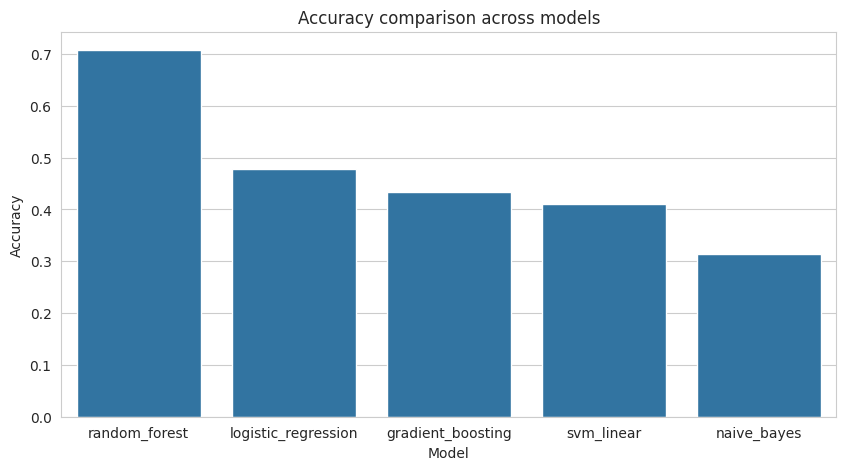

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data = metrics_df,
    x = "model",
    y = "accuracy"
)

plt.title("Accuracy comparison across models")
plt.ylabel("Accuracy")
plt.xlabel("Model")


plt.show()

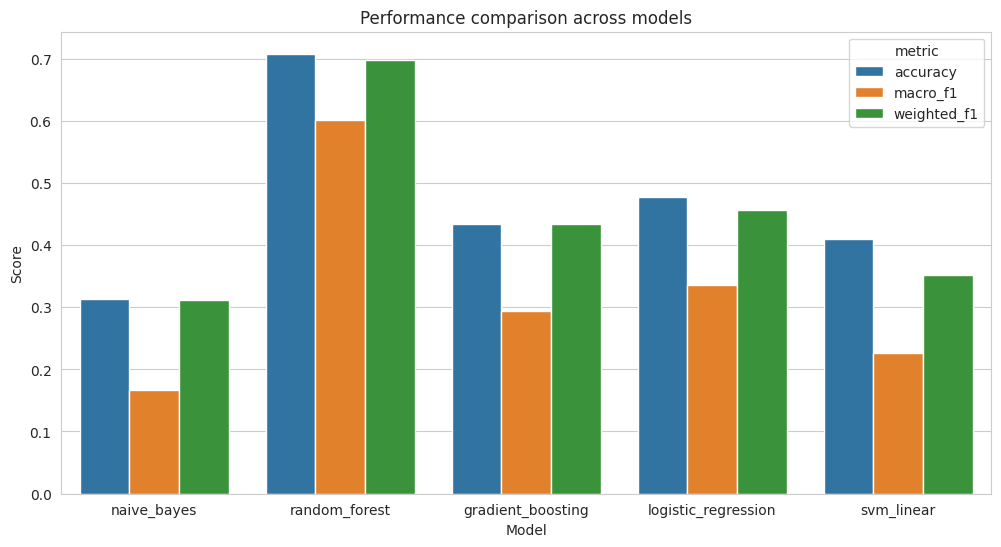

In [20]:
metrics_long = metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=metrics_long,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Performance comparison across models")
plt.ylabel("Score")
plt.xlabel("Model")

# plt.xticks(rotation=45)

plt.show()

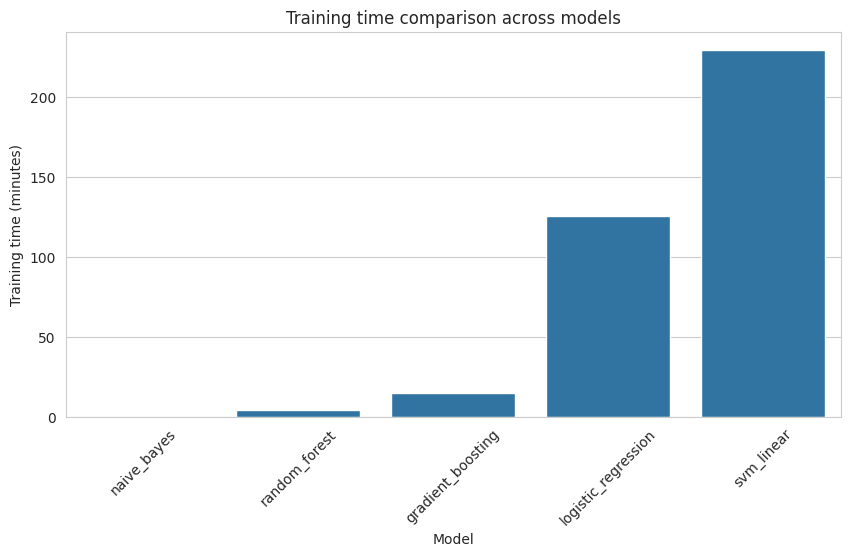

In [19]:
metrics_df["training_time_minutes"] = metrics_df["training_time_seconds"] / 60
metrics_df = metrics_df.sort_values("training_time_minutes")
plt.figure(figsize=(10,5))

sns.barplot(
    data=metrics_df,
    x="model",
    y="training_time_minutes"
)

plt.title("Training time comparison across models")
plt.ylabel("Training time (minutes)")
plt.xlabel("Model")

plt.xticks(rotation=45)

plt.show()
 

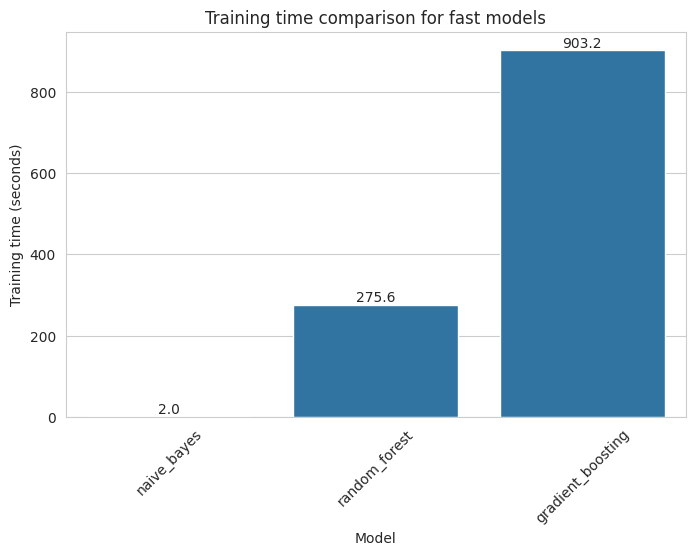

In [17]:
fast_models = ["random_forest", "gradient_boosting", "naive_bayes"]

fast_df = metrics_df[metrics_df["model"].isin(fast_models)].copy()
fast_df = fast_df.sort_values("training_time_seconds")

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=fast_df,
    x="model",
    y="training_time_seconds"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Training time comparison for fast models")
plt.ylabel("Training time (seconds)")
plt.xlabel("Model")

plt.xticks(rotation=45)

plt.show()

In [ ]:
def load_model_sizes(results_dir: Path):
    rows = []

    for model_dir in results_dir.iterdir():
        if not model_dir.is_dir():
            continue

        model_path = model_dir / "model.pkl"
        
        if not model_path.exists():
            print(f"model.pkl file does not exist in {model_dir}")
            continue
        
        size_bytes = model_path.stat().st_size
        rows.append({
            "model": model_dir.name, 
            "model_size_MB": size_bytes / (1024 * 1024)
        })
    
    # Spec slucaj: model prevelik i nije sacuvan u results direktorijumu, pogledati izvestaj
    rows.append({
        "model": "random_forest",
        "model_size_MB": 9000
    })

    return pd.DataFrame(rows)

sizes_df = load_model_sizes(RESULTS_DIR)
sizes_df

model.pkl file does not exist in ../results/random_forest


,model,model_size_MB
0,naive_bayes,1.567359
1,gradient_boosting,10.511765
2,logistic_regression,0.402337
3,svm,0.793767
4,random_forest,9000.000000


In [26]:
metrics_df = metrics_df.merge(sizes_df, on = "model")
metrics_df

,model,accuracy,macro_f1,weighted_f1,training_time_seconds,training_time_minutes,model_size_MB
0,naive_bayes,0.313359,0.166865,0.311437,2.001867,0.033364,1.567359
1,random_forest,0.708096,0.600420,0.697774,275.634809,4.593913,9000.000000
2,gradient_boosting,0.434554,0.294551,0.434436,903.243607,15.054060,10.511765
3,logistic_regression,0.477680,0.336350,0.456242,7540.573148,125.676219,0.402337


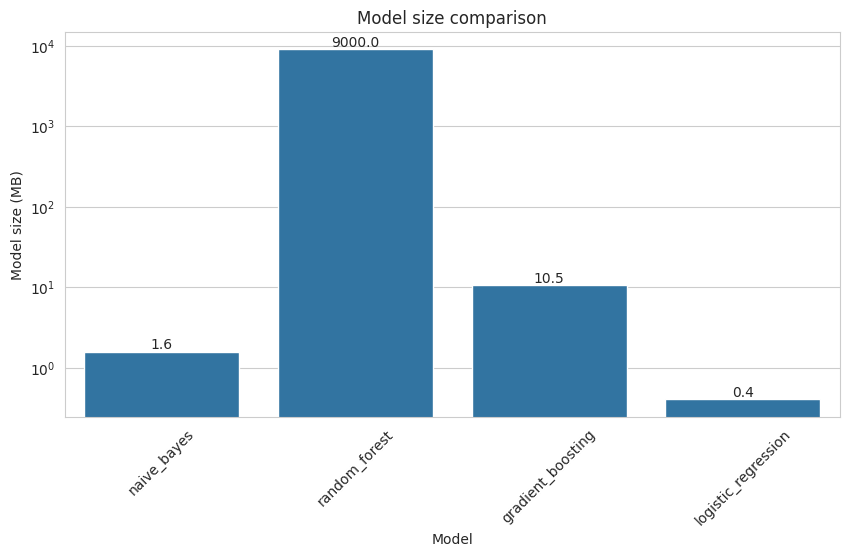

In [36]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data = metrics_df,
    x="model",
    y="model_size_MB"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Model size comparison")
plt.ylabel("Model size (MB)")
plt.xlabel("Model")

plt.yscale("log")

plt.xticks(rotation=45)

plt.show()

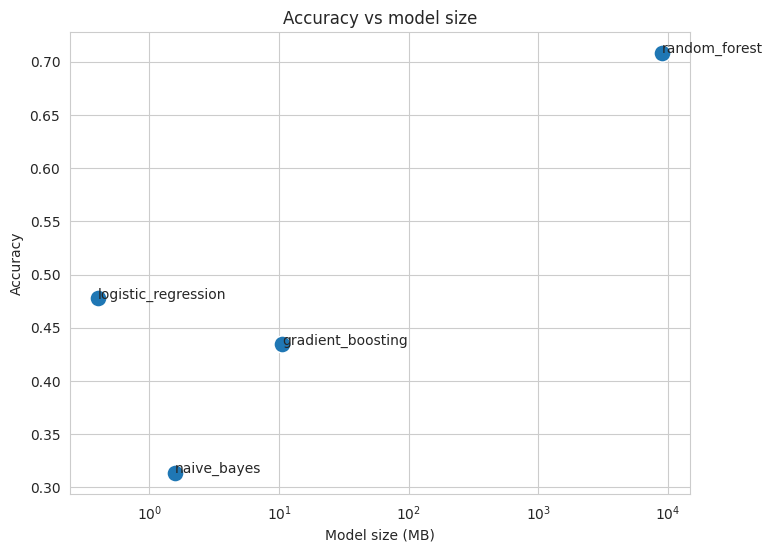

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=metrics_df,
    x="model_size_MB",
    y="accuracy",
    s=150
)

for _, row in metrics_df.iterrows():
    plt.text(
        row["model_size_MB"],
        row["accuracy"],
        row["model"]
    )

plt.xscale("log")

plt.title("Accuracy vs model size")
plt.xlabel("Model size (MB)")
plt.ylabel("Accuracy")

plt.show()

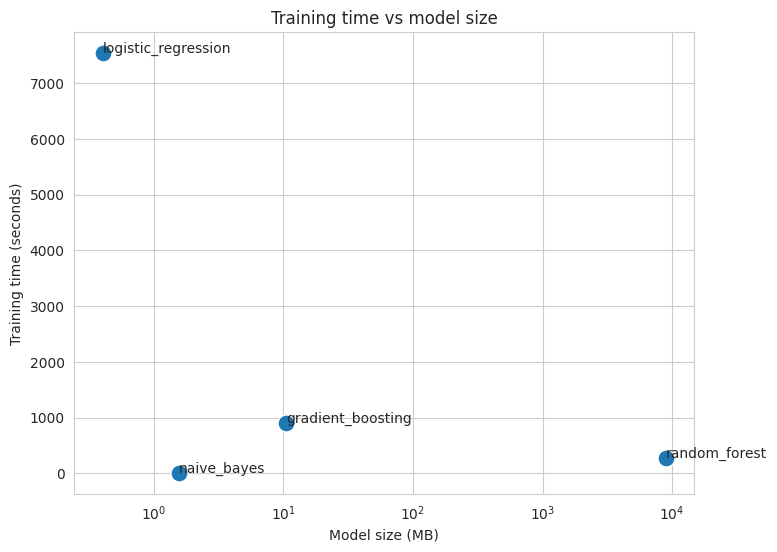

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=metrics_df,
    x="model_size_MB",
    y="training_time_seconds",
    s=150
)

for _, row in metrics_df.iterrows():
    plt.text(
        row["model_size_MB"],
        row["training_time_seconds"],
        row["model"]
    )

plt.xscale("log")

plt.title("Training time vs model size")
plt.xlabel("Model size (MB)")
plt.ylabel("Training time (seconds)")

plt.show()

In [40]:
def load_pca_results(results_dir: Path):
    rows = []

    for model_dir in results_dir.iterdir():

        pca_path = model_dir / "pca_comparison.csv"

        if not pca_path.exists():
            continue

        df = pd.read_csv(pca_path)


        rows.append(df)

    return pd.concat(rows, ignore_index=True)

pca_df = load_pca_results(RESULTS_DIR)
pca_df

,Model,accuracy,Macro F1,Weighted_F1
0,Naive Bayes,0.313359,0.166865,0.311437
1,Naive Bayes + PCA,0.395379,0.272392,0.399755
2,Random Forest,0.708096,0.600420,0.697774
3,Random Forest + PCA,0.633306,0.524800,0.615194
4,Gradient Boosting,0.434554,0.294551,0.434436
5,Gradient Boosting + PCA,0.420827,0.282567,0.408115
6,Logistic Regression,0.477680,0.336350,0.456242
7,Logistic Regression + PCA,0.462650,0.313373,0.436223
8,SVM,0.410235,0.226577,0.352163
9,SVM + PCA,0.386161,0.184060,0.317281


In [ ]:
# Split base models and PCA models
base_df = pca_df[~pca_df["Model"].str.contains("PCA")].copy()
pca_only_df = pca_df[pca_df["Model"].str.contains("PCA")].copy()

# Remove " + PCA" from model names
pca_only_df["Model"] = pca_only_df["Model"].str.replace(" + PCA", "", regex=False)

# Rename PCA metric columns
pca_only_df = pca_only_df.rename(columns={
    "accuracy": "accuracy_pca",
    "Macro F1": "macro_f1_pca",
    "Weighted_F1": "weighted_f1_pca"
})

# Keep only PCA metrics
pca_only_df = pca_only_df[
    ["Model", "accuracy_pca", "macro_f1_pca", "weighted_f1_pca"]
]

# Merge base metrics with PCA metrics
pca_comparison_df = base_df.merge(pca_only_df, on = "Model")

# Optional: compute delta (effect of PCA)
pca_comparison_df["accuracy_delta"] = (
    pca_comparison_df["accuracy_pca"] - pca_comparison_df["accuracy"]
)

pca_comparison_df

,Model,accuracy,Macro F1,Weighted_F1,accuracy_pca,macro_f1_pca,weighted_f1_pca,accuracy_delta
0,Naive Bayes,0.313359,0.166865,0.311437,0.395379,0.272392,0.399755,0.082019
1,Random Forest,0.708096,0.600420,0.697774,0.633306,0.524800,0.615194,-0.074790
2,Gradient Boosting,0.434554,0.294551,0.434436,0.420827,0.282567,0.408115,-0.013727
3,Logistic Regression,0.477680,0.336350,0.456242,0.462650,0.313373,0.436223,-0.015030
4,SVM,0.410235,0.226577,0.352163,0.386161,0.184060,0.317281,-0.024073


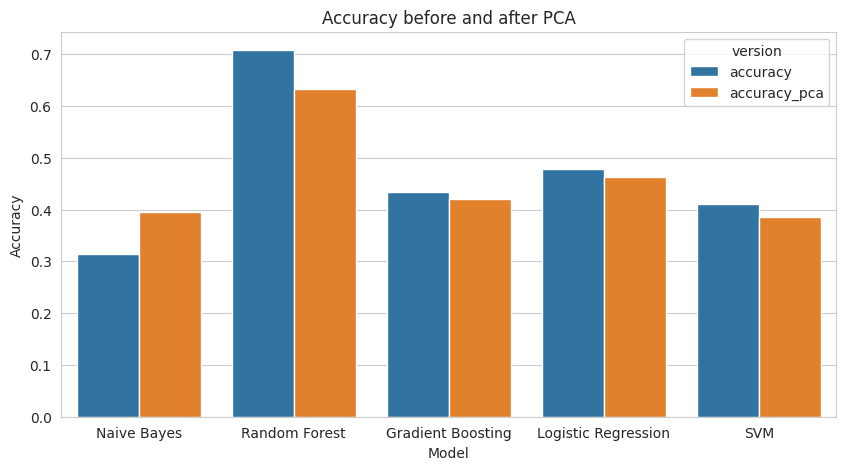

In [47]:

plot_df = pca_comparison_df.melt(
    id_vars="Model",
    value_vars=["accuracy", "accuracy_pca"],
    var_name="version",
    value_name="score"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=plot_df,
    x="Model",
    y="score",
    hue="version"
)

plt.title("Accuracy before and after PCA")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

In [48]:
def load_italic_results(results_dir: Path):

    rows = []

    for model_dir in results_dir.iterdir():

        italic_path = model_dir / "italic_accuracy.csv"

        if not italic_path.exists():
            continue

        df = pd.read_csv(italic_path)

        df["model"] = model_dir.name

        rows.append(df)

    return pd.concat(rows, ignore_index=True)

italic_df = load_italic_results(RESULTS_DIR)
italic_df

,italic,samples,accuracy,accuracy_%,model
0,0,116206,0.403921,40.39,naive_bayes
1,1,50328,0.104256,10.43,naive_bayes
2,0,116206,0.783428,78.34,random_forest
3,1,50328,0.534156,53.42,random_forest
4,0,116206,0.515335,51.53,gradient_boosting
5,1,50328,0.248033,24.80,gradient_boosting
6,0,116206,0.571296,57.13,logistic_regression
7,1,50328,0.261524,26.15,logistic_regression
8,0,116206,0.510395,51.04,svm
9,1,50328,0.178966,17.90,svm


In [50]:
italic_df["font_style"] = italic_df["italic"].map({
    0: "normal",
    1: "italic"
})

italic_df

,italic,samples,accuracy,accuracy_%,model,font_style
0,0,116206,0.403921,40.39,naive_bayes,normal
1,1,50328,0.104256,10.43,naive_bayes,italic
2,0,116206,0.783428,78.34,random_forest,normal
3,1,50328,0.534156,53.42,random_forest,italic
4,0,116206,0.515335,51.53,gradient_boosting,normal
5,1,50328,0.248033,24.80,gradient_boosting,italic
6,0,116206,0.571296,57.13,logistic_regression,normal
7,1,50328,0.261524,26.15,logistic_regression,italic
8,0,116206,0.510395,51.04,svm,normal
9,1,50328,0.178966,17.90,svm,italic


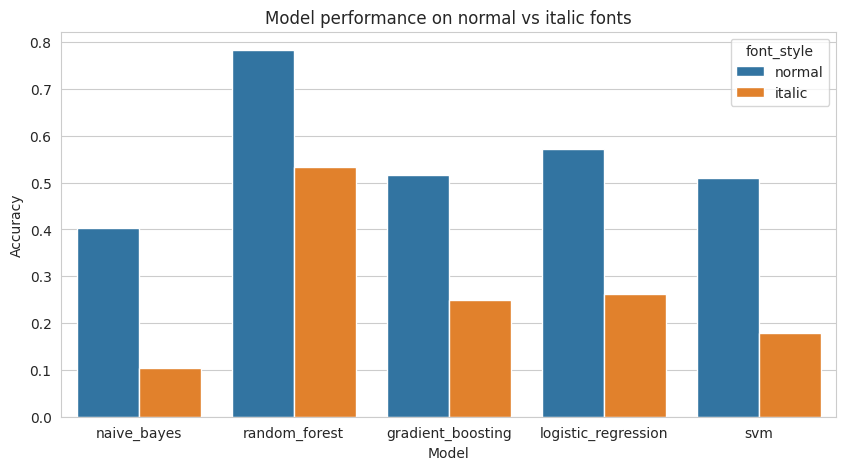

In [51]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=italic_df,
    x="model",
    y="accuracy",
    hue="font_style"
)

plt.title("Model performance on normal vs italic fonts")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

### Font accuracy across models

In [ ]:
def load_font_accuracy(results_dir: Path):

    rows = []

    for model_dir in results_dir.iterdir():

        font_path = model_dir / "font_accuracy.csv"

        if not font_path.exists():
            continue

        df = pd.read_csv(font_path)

        df["model"] = model_dir.name

        rows.append(df)

    return pd.concat(rows, ignore_index = True)

font_df = load_font_accuracy(RESULTS_DIR)

font_df.head()

,font,samples,accuracy,accuracy_%,model
0,E13B,4718,0.851632,85.16,naive_bayes
1,OCRB,18706,0.825404,82.54,naive_bayes
2,NUMERICS,2780,0.796763,79.68,naive_bayes
3,OCRA,13077,0.778084,77.81,naive_bayes
4,VIN,218,0.733945,73.39,naive_bayes


In [53]:
font_difficulty = (
    font_df
    .groupby("font")["accuracy"]
    .mean()
    .sort_values(ascending = False)
    .reset_index()
)

font_difficulty

,font,accuracy
0,E13B,0.922721
1,NUMERICS,0.886619
2,OCRB,0.869101
3,VIN,0.843119
4,OCRA,0.838434
...,...,...
148,SERIF,0.118035
149,SCRIPT,0.105023
150,EDWARDIAN,0.103371
151,SKETCHFLOW,0.101205


In [54]:
top_fonts = font_difficulty.head(10)
top_fonts

,font,accuracy
0,E13B,0.922721
1,NUMERICS,0.886619
2,OCRB,0.869101
3,VIN,0.843119
4,OCRA,0.838434
5,MONEY,0.811074
6,BITSTREAMVERA,0.700000
7,HANDPRINT,0.694685
8,CALISTO,0.582105
9,BELL,0.575269


In [55]:
worst_fonts = font_difficulty.tail(10)
worst_fonts

,font,accuracy
143,EBRIMA,0.141062
144,COURIER,0.140507
145,KUNSTLER,0.131792
146,BUXTON,0.130021
147,TAHOMA,0.122093
148,SERIF,0.118035
149,SCRIPT,0.105023
150,EDWARDIAN,0.103371
151,SKETCHFLOW,0.101205
152,YI BAITI,0.081095


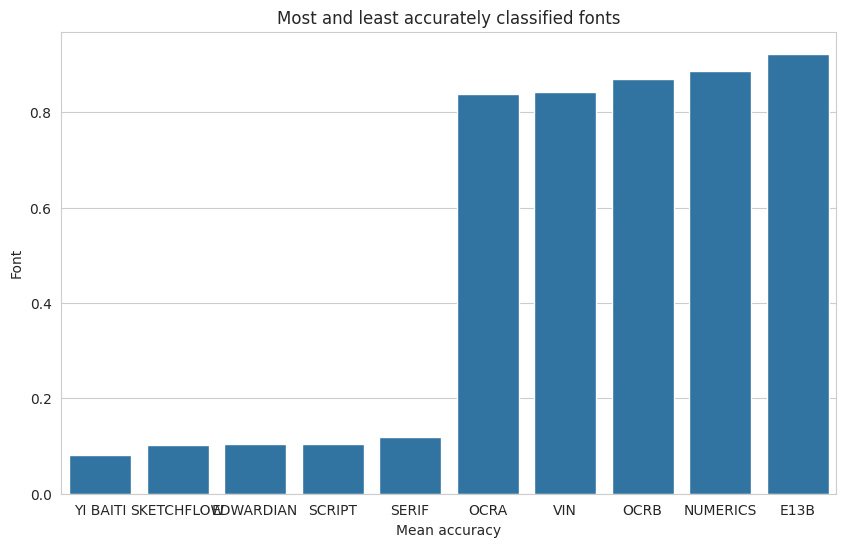

In [ ]:
font_extremes = pd.concat([
    font_difficulty.head(5),
    font_difficulty.tail(5)
])

font_extremes = font_extremes.sort_values("accuracy")

plt.figure(figsize=(10,6))

sns.barplot(
    data=font_extremes,
    x="accuracy",
    y="font"
)

plt.title("Most and least accurately classified fonts")
plt.xlabel("Mean accuracy")
plt.ylabel("Font")

plt.show()